In [209]:
import os

import numpy as np
import torch
import torch.nn as nn
import wfdb.processing
import torch.nn.functional as F
from tqdm import tqdm
import keras
import tensorflow as tf
import scipy
import time
from tqdm import tqdm

### Miejsce na model

In [210]:
class ResNetBlock(nn.Module):
    def __init__(self,in_channels, out_channels):
        """
        output same as input
        """
        super(ResNetBlock, self).__init__()
        self.conv1 = nn.Sequential(
                        nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
                        nn.BatchNorm1d(out_channels),
                        nn.ReLU(inplace=False))  # Changed inplace to False
        self.conv2 = nn.Sequential(
                        nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                        nn.BatchNorm1d(out_channels),
                        nn.ReLU(inplace=False))
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        if(in_channels != out_channels):
            self.residual = nn.Sequential(
                nn.Conv1d(self.in_channels, out_channels, kernel_size=1, stride=1),
                nn.BatchNorm1d(out_channels),
            )

    def forward(self,x):
        out = self.conv1(x)
        out = self.conv2(out)
        if self.in_channels != self.out_channels:
            residual = self.residual(x)
        else:
            residual = x
        return F.relu(out + residual, inplace=False)


class ResNetLike(nn.Module):
    def __init__(self, input = 201, input_ch = 1, num_classes = 2):
        super(ResNetLike, self).__init__()
        self.model = nn.Sequential(
            nn.Conv1d(input_ch, 64, kernel_size=7, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            ResNetBlock(64,64),
            ResNetBlock(64,64),
            ResNetBlock(64,64),
            ResNetBlock(64,128),    # out 1 x 128 x n
            nn.MaxPool1d(2),        # out 1 x 128 x n//2
            ResNetBlock(128,128),
            ResNetBlock(128,128),
            ResNetBlock(128,256),
            nn.MaxPool1d(2),        # out 1 x 256 x n//2
            ResNetBlock(256,256),
            ResNetBlock(256,256),
            ResNetBlock(256,512),
            nn.MaxPool1d(2),        # out 1 x 512 x n//8
            nn.Flatten(),
            nn.Linear(512*(input//8), 256),
            nn.Dropout(0.5),
            nn.Sigmoid(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):

        return self.model(x)
    
    def train_model(self, train_loader, valid_loader, num_epochs = 5, learning_rate=0.001, save_best = False, save_thr = 0.94):
        best_accuracy = 0.0
        total_step = len(train_loader)
        # Loss and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.RMSprop(self.parameters(), lr=learning_rate, weight_decay = 0.005, momentum = 0.9)  

        for epoch in range(num_epochs):
            # self.train()
            correct = 0
            total = 0
            for i, (images, labels) in enumerate(tqdm(train_loader)):
                # Move tensors to the configured device
                images = images.float()
                labels = labels.type(torch.LongTensor)
                labels = labels


                optimizer.zero_grad()

                # Forward pass
                outputs = self.forward(images)
                loss = criterion(outputs, labels)
                # Backward and optimize
                loss.backward()
                
                optimizer.step()

                # accuracy
                _, predicted = torch.max(outputs.data, 1)
                correct += (torch.eq(predicted, labels)).sum().item()
                total += labels.size(0)

                del images, labels, outputs

            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.4f}'
                            .format(epoch+1, num_epochs, i+1, total_step, loss.item(), (float(correct))/total))


            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            # Validation
            with torch.no_grad():
                correct = 0
                total = 0
                for images, labels in valid_loader:
                    images = images.float()
                    labels = labels
                    outputs = self.forward(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (torch.eq(predicted, labels)).sum().item()
                    del images, labels, outputs
                if(((100 * correct / total) > best_accuracy) and save_best and ((100 * correct / total) > save_thr)):
                    torch.save(self.state_dict(), "best_resnet50_MINST-DVS2.pt")

                print('Accuracy of the network: {} %'.format( 100 * correct / total))

### Evaluacja

In [211]:
def bce_dice_weighted_loss_wrapper(bce_w, dice_w, smooth=10e-6):
    bce_loss = keras.losses.BinaryCrossentropy()
    dice_loss = dice_coef_loss_wrapper(smooth)
    def bce_dice_weighted_loss(y_true, y_pred):
        return bce_w * bce_loss(y_true, y_pred) + dice_w * dice_loss(y_true, y_pred)
    return bce_dice_weighted_loss

def dice_coef_wrapper(smooth=10e-6):
    def dice_coef(y_true, y_pred):
        y_true_f = y_true
        y_pred_f = y_pred
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        dice = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)
        return dice
    return dice_coef


def dice_coef_loss_wrapper(smooth=10e-6):
    dice_coef = dice_coef_wrapper(smooth)
    def dice_coef_loss(y_true, y_pred):
        return 1 - dice_coef(y_true, y_pred)
    return dice_coef_loss


In [212]:
class RecordEvaluator:
    def __init__(self, dest_dir):
        self._dest_dir = dest_dir
        self._model = ResNetLike()
        self._model.load_state_dict(torch.load("best_resnet50_afdb_filtration_20Hz_cpu.pt", weights_only=True))
        self._model.eval()
        self.iteration = 0

    def evaluate(self, signal_reader):
        signal = signal_reader.read_signal()[:,0]
        fs = signal_reader.read_fs()
        if self.iteration != 0:
            pred = np.zeros([len(signal), ], dtype=np.float32)
            code = signal_reader.get_code()
            np.save(os.path.join(self._dest_dir, f'{code}'), pred)

        self.iteration +=1
        
        starttime = time.time()
        cutOff = 20
        b, a = scipy.signal.butter(5, cutOff, fs=fs, btype='low', analog=False)
        signal = scipy.signal.lfilter(b,a,signal)

        fs_conv = 20
        num_samples_target = int(len(signal) * fs_conv / fs)
        resampled_signal = scipy.signal.resample(signal, num_samples_target)
        resampled_labels = np.zeros(len(resampled_signal))
        endtime = time.time()
        print('preprocessing ', endtime-starttime)
        starttime = time.time()
        for idx in tqdm(range(100,len(resampled_labels)-101, 100)):
            input = [resampled_signal[idx-100:idx+101]]
            input = torch.Tensor(input).unsqueeze(0)
            outputs = self._model.forward(input)
            _, predicted = torch.max(outputs.data, 1)
            resampled_labels[idx-50:idx+51] = predicted
        endtime = time.time()
        print('evaluation ', endtime-starttime)

        starttime = time.time()
        pred = np.zeros([len(signal), ], dtype=np.float32)
        for i in range(len(pred)):
            try:
                pred[i] = resampled_labels[min(int(i * fs_conv / fs), len(resampled_labels)-1)]
            except:
                print(int(i * fs_conv / fs), fs_conv, fs, len(resampled_labels))
        endtime = time.time()
        print('last resampling ', endtime-starttime)
        return pred, resampled_labels
        # code = signal_reader.get_code()
        # np.save(os.path.join(self._dest_dir, f'{code}'), pred)

In [213]:
class SignalReader:
    def __init__(self, name, dataset_dir = 'Datasets/files/'):
        self.record = wfdb.rdsamp(f"{dataset_dir}{name}") 
        self.annotation = wfdb.rdann(f"{dataset_dir}{name}", 'atr')
        self.signal = self.record[0]
        self.gt = np.zeros([len(self.signal), ], dtype=np.float32)


        if(len(self.annotation.sample)==1):
            idx_next = len(self.signal)
        else:
            idx_next = self.annotation.sample[1]
        label_t = self.annotation.aux_note[0]
        temp_aux = 0
        for idx in range(self.annotation.sample[0],len(self.signal)):
            while(idx>=idx_next):
                temp_aux += 1
                if(temp_aux!=len(self.annotation.sample)-1):
                    idx_next = self.annotation.sample[temp_aux+1]
                else:
                    idx_next = len(self.signal)
                label_t = self.annotation.aux_note[temp_aux]
            if(label_t == '(AFIB'):
                self.gt[idx] = 1
            else:
                self.gt[idx] = 0

    
    def read_signal(self):
        return self.signal

    def read_fs(self):
        return self.record[1]["fs"]

In [214]:

record_eval = RecordEvaluator('./')
signal_reader = SignalReader('06995')
seg, resampl_pred = record_eval.evaluate(signal_reader)
gt = signal_reader.gt


preprocessing  0.38856959342956543


100%|██████████| 7363/7363 [00:57<00:00, 127.27it/s]


evaluation  57.855470418930054
last resampling  5.846977949142456


In [215]:
print(max(gt))
print(signal_reader.annotation.sample)
print(signal_reader.annotation.aux_note)

1.0
[      7 1381607 1383575 1387965 1389204 1399238 1856046 1864114 3789346
 3793222 6274349]
['(AFIB', '(AFL', '(AFIB', '(AFL', '(AFIB', '(N', '(AFIB', '(N', '(AFIB', '(N', '(AFIB']


In [216]:
seg[gt==1]
np.sum(seg[gt==1]==1)*2.0
dice = np.sum(seg[gt==1]==1)*2.0 / (np.sum(seg[seg==1]==1) + np.sum(gt[gt==1]==1))

In [217]:
print(dice)

0.6266064425639404


In [218]:
print(len(seg))

9205760


In [219]:
print(len(gt))

9205760


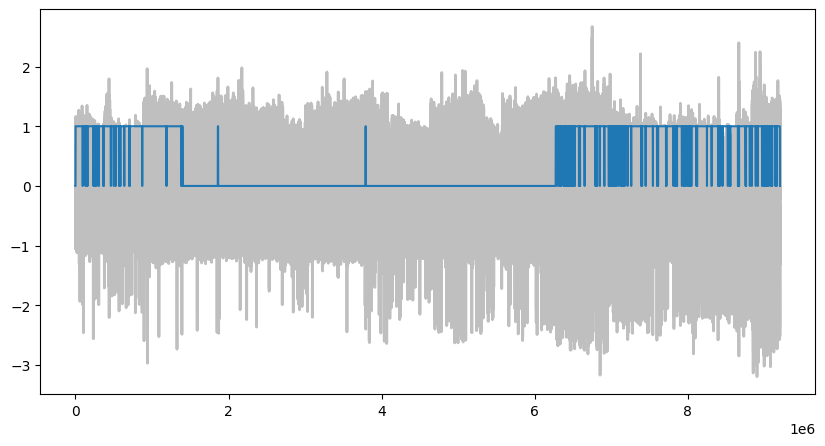

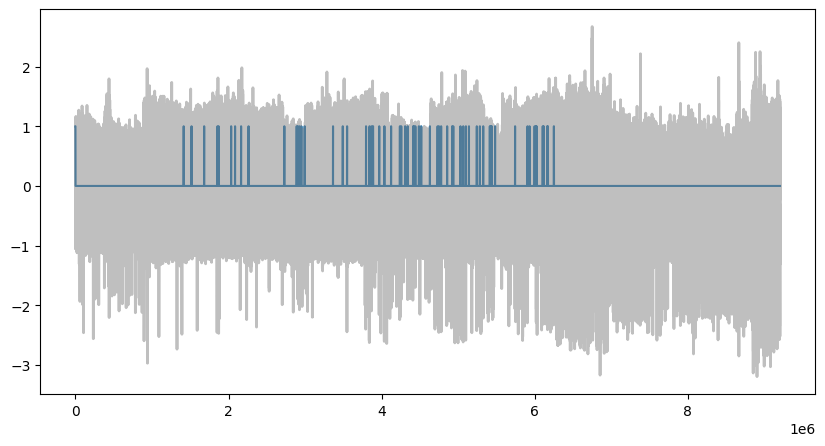

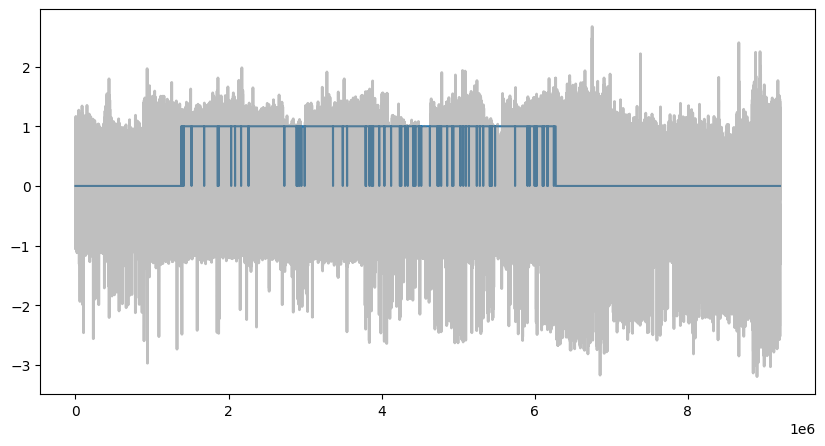

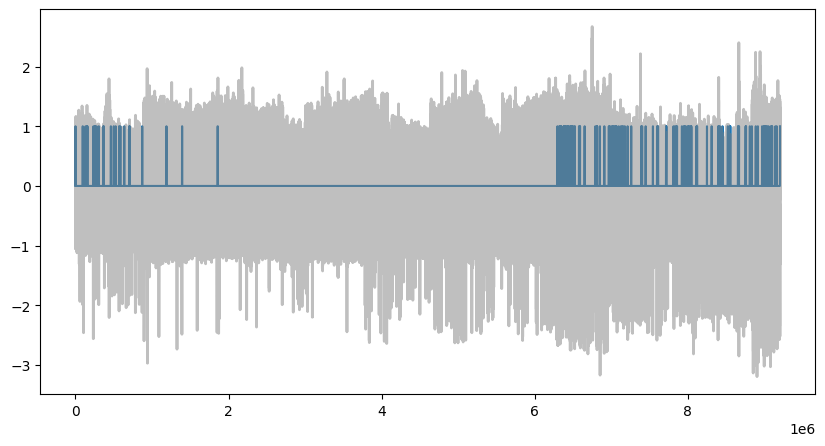

In [224]:
import numpy as np
import matplotlib.pyplot as plt
pred = seg
background_signal = signal_reader.read_signal()[:, 0]
# Identify TP, FP, TN, FN
TP = (pred == 1) & (gt == 1)
FP = (pred == 1) & (gt == 0)
TN = (pred == 0) & (gt == 0)
FN = (pred == 0) & (gt == 1)

# Define color map for segments
color_map = {
    'TP': 'green',
    'FP': 'red',
    'TN': 'blue',
    'FN': 'yellow'
}
# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(range(len(background_signal)), background_signal, color='gray', label='Background Signal', linewidth=2, alpha=0.5)

# Highlight segments based on classification
plt.plot(TP)
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(TN)
plt.plot(range(len(background_signal)), background_signal, color='gray', label='Background Signal', linewidth=2, alpha=0.5)
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(FP)
plt.plot(range(len(background_signal)), background_signal, color='gray', label='Background Signal', linewidth=2, alpha=0.5)
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(FN)
plt.plot(range(len(background_signal)), background_signal, color='gray', label='Background Signal', linewidth=2, alpha=0.5)
plt.show()



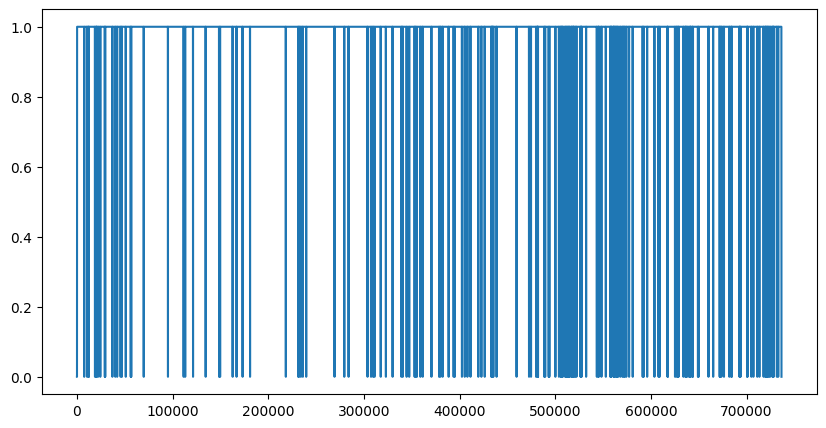

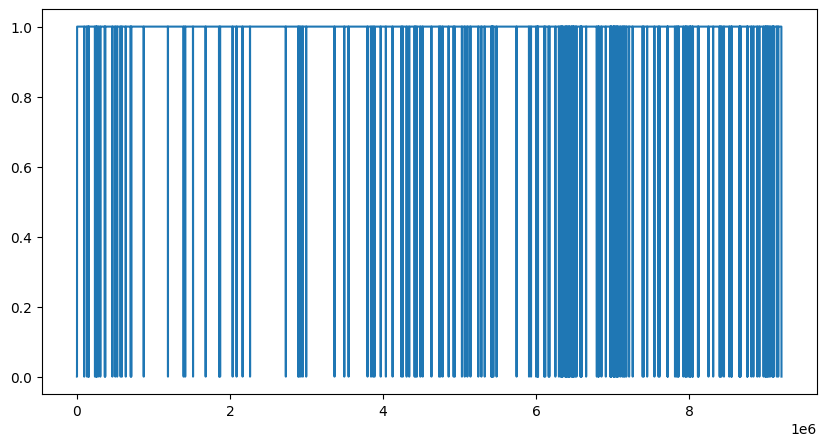

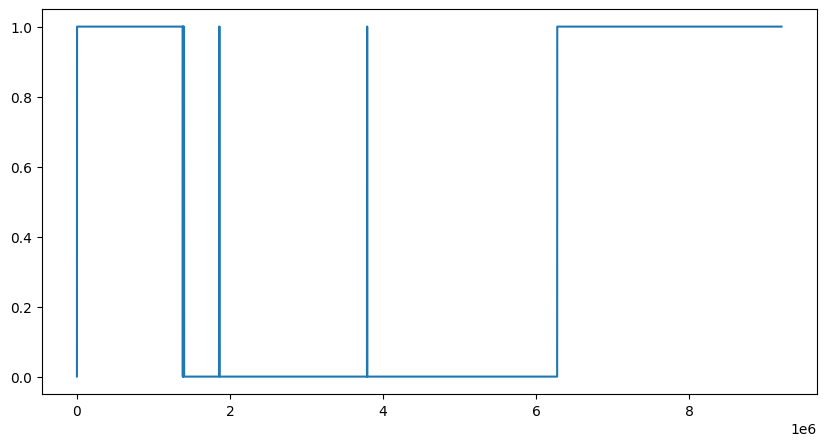

In [225]:
plt.figure(figsize=(10, 5))
plt.plot(resampl_pred)
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(pred)
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(gt)
plt.show()

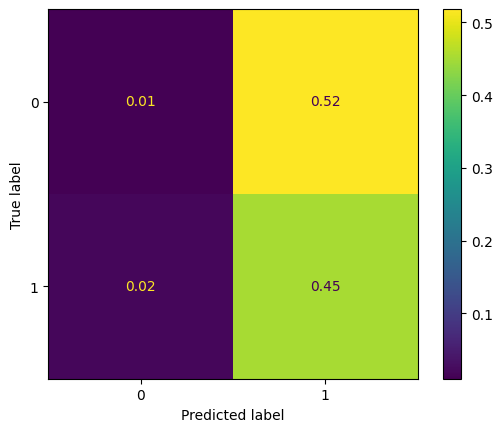

In [222]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def normalize_confusion_matrix(cm, norm='true'):
    cm_normalized = cm.astype('float') / cm.sum()
    return cm_normalized
cm = confusion_matrix(gt, pred)
cm = normalize_confusion_matrix(cm, norm='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()